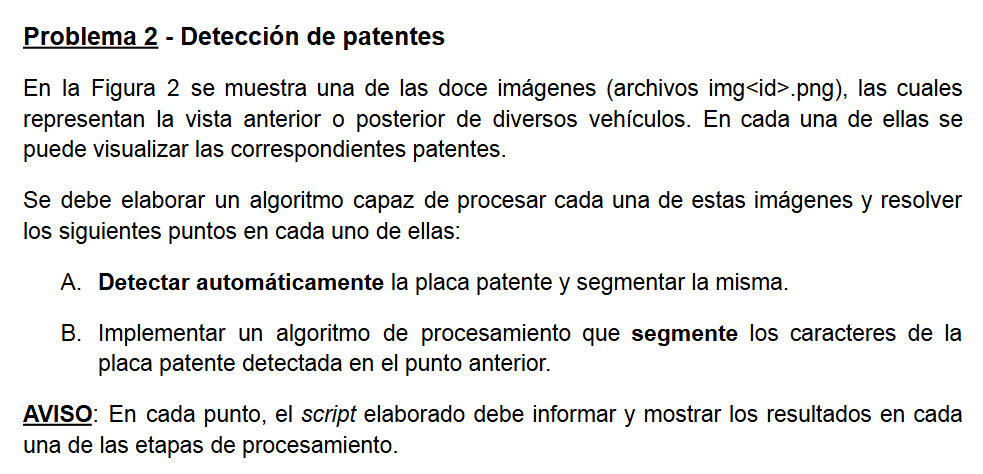

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

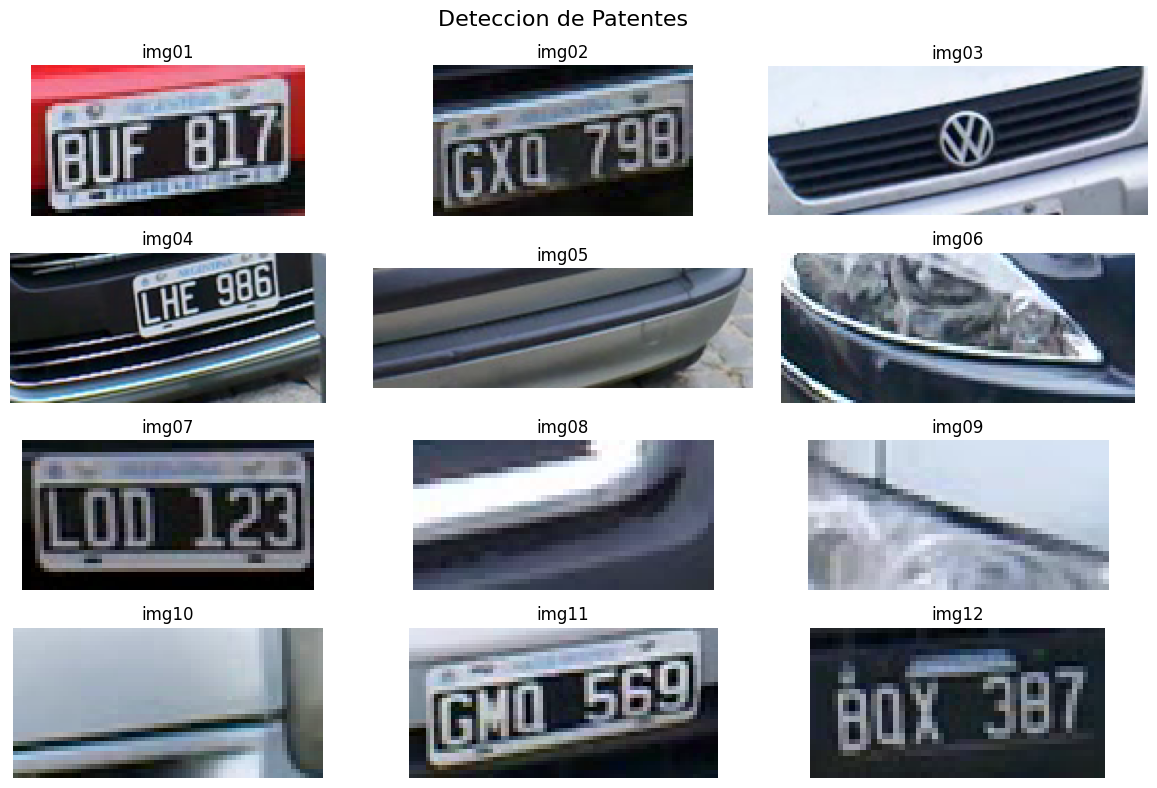

In [ ]:
def obtener_recorte_patente(path):
    img = cv2.imread(path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    thresh = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    thresh = cv2.dilate(cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3))), None)

    #candidatos
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []

    
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / h
        if 1.5 < aspect < 5.0 and w*h > 80 and 15 < h < 100:
            candidatos.append((x, y, w, h))

    if not candidatos: return None
    

    #seleccion
    H, W = img.shape[:2]
    
    def calcular_puntaje(r):
        x, y, w, h = r
        # Puntos por ratio (ideal 3.0) + Posición Y (centro-abajo) + Centrado X
        s_ratio = max(0, 10 - abs(w/h - 3.0) * 2)
        s_pos_y = 5 if 0.3 < y/H < 0.85 else 0
        s_centrado = 3 if abs(W//2 - (x + w//2)) < W*0.2 else 0
        return s_ratio + s_pos_y + s_centrado

    x, y, w, h = max(candidatos, key=calcular_puntaje)

    pad = 5
    return img[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]




resultados_crops = []
nombres_archivos = []

for i in range(1, 13):
    nombre_archivo = f'img/img{i:02d}.png' 
    recorte = obtener_recorte_patente(nombre_archivo)
    
    if recorte is not None:
        resultados_crops.append(recorte)
        nombres_archivos.append(f"img{i:02d}")
    else:
        placeholder = np.zeros((50, 150, 3), dtype=np.uint8)
        resultados_crops.append(placeholder)
        nombres_archivos.append(f"img{i:02d} (Falló)")


fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle('Deteccion de Patentes', fontsize=16)

axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(resultados_crops):
        img_rgb = cv2.cvtColor(resultados_crops[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(nombres_archivos[i])
        ax.axis('off')

plt.tight_layout()
plt.show()

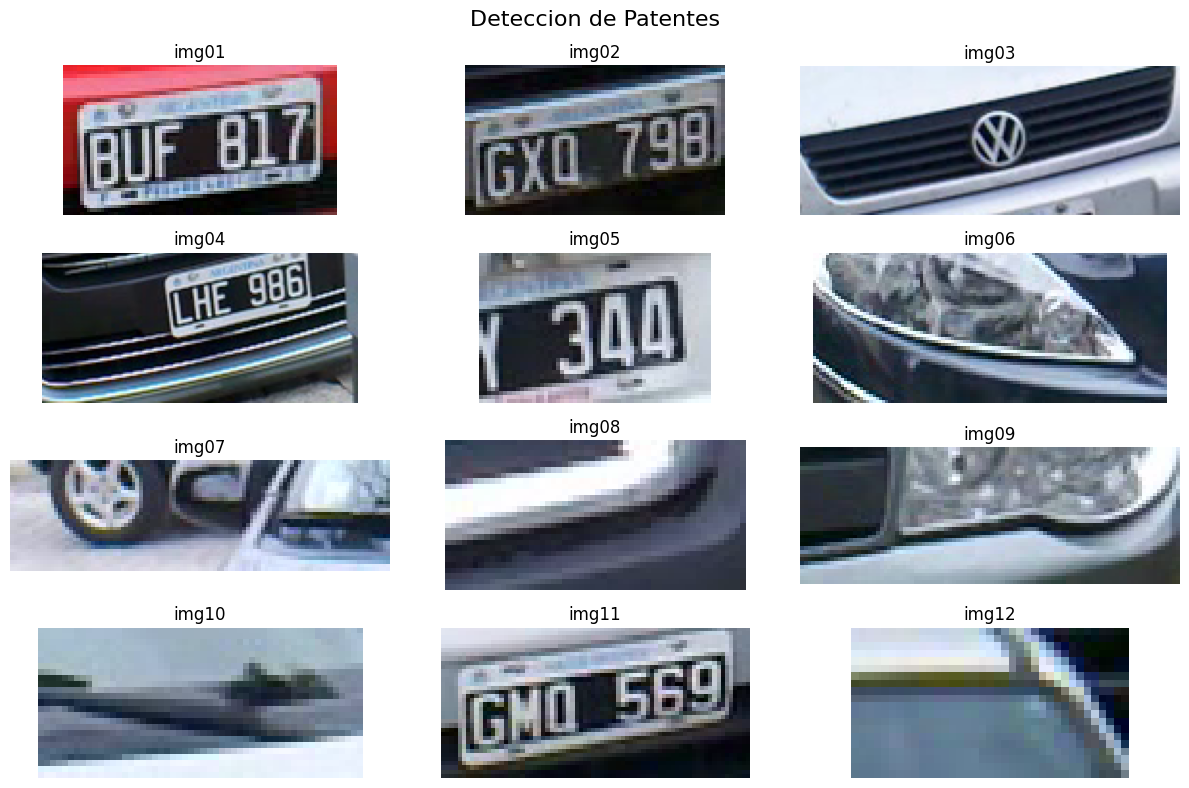

In [ ]:
def obtener_recorte_patente(path):
    img = cv2.imread(path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    kernel_shape = (13, 5) 
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_shape)
    
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    
    thresh = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    thresh = cv2.dilate(cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3))), None)

    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []

    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / h
        if 1.5 < aspect < 6.0 and w*h > 100 and 12 < h < 120:
            candidatos.append((x, y, w, h))

    if not candidatos: return None

    H, W = img.shape[:2]

    def calcular_puntaje(r):
        x, y, w, h = r
        
        roi = gray[y:y+h, x:x+w]
        
        mean, std = cv2.meanStdDev(roi)
        score_texture = std[0][0] 

        diff_ratio = abs((w/h) - 3.0)
        score_shape = max(0, 20 - (diff_ratio * 5))

        roi_thresh = thresh[y:y+h, x:x+w]
        white_pixels = cv2.countNonZero(roi_thresh)
        area = w * h
        density = white_pixels / area
        score_density = 10 if 0.2 < density < 0.7 else 0

        final_score = (score_texture * 2.5) + score_shape + score_density
        
        return final_score

    best_rect = max(candidatos, key=calcular_puntaje)
    x, y, w, h = best_rect

    pad = 5
    return img[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]





resultados_crops = []
nombres_archivos = []

for i in range(1, 13):
    nombre_archivo = f'img/img{i:02d}.png' 
    recorte = obtener_recorte_patente(nombre_archivo)
    
    if recorte is not None:
        resultados_crops.append(recorte)
        nombres_archivos.append(f"img{i:02d}")
    else:
        placeholder = np.zeros((50, 150, 3), dtype=np.uint8)
        resultados_crops.append(placeholder)
        nombres_archivos.append(f"img{i:02d} (Falló)")


fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle('Deteccion de Patentes', fontsize=16)

axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(resultados_crops):
        img_rgb = cv2.cvtColor(resultados_crops[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(nombres_archivos[i])
        ax.axis('off')

plt.tight_layout()
plt.show()